# PyTorch Basics — Tensors, Autograd, Modules


| Feature | Meaning |
|---|---|
| `age_hours` | how long the ticket has been open |
| `n_replies` | how many times the customer has replied |
| `neg_score` | sentiment negativity, 0 to 1 |



---
## 1. Setup

Fix the seed so every run is identical, and pick the best available device. **This exact block goes at the top of every notebook in this course.**

In [1]:
import random
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, TensorDataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print("torch version :", torch.__version__)
print("device        :", device)

torch version : 2.12.0
device        : mps


---
## 2. Creating tensors

A tensor is an n-dimensional array. The number of dimensions is its **rank**.

```text
rank 0  scalar   3.7                shape ()
rank 1  vector   [1,2,3]            shape (3,)
rank 2  matrix   [[1,2],[3,4]]      shape (2,2)
rank 4  images   batch of pictures  shape (N,C,H,W)
```

In [2]:
print("from list  :", torch.tensor([[1., 2.], [3., 4.]]))
print("zeros     :", torch.zeros(2, 3))
print("ones      :", torch.ones(2, 3))
print("arange    :", torch.arange(0, 10, 2))
print("linspace  :", torch.linspace(0, 1, 5))
print("randn     :", torch.randn(2, 3))
print("eye       :", torch.eye(3))

from list  : tensor([[1., 2.],
        [3., 4.]])
zeros     : tensor([[0., 0., 0.],
        [0., 0., 0.]])
ones      : tensor([[1., 1., 1.],
        [1., 1., 1.]])
arange    : tensor([0, 2, 4, 6, 8])
linspace  : tensor([0.0000, 0.2500, 0.5000, 0.7500, 1.0000])
randn     : tensor([[ 0.3367,  0.1288,  0.2345],
        [ 0.2303, -1.1229, -0.1863]])
eye       : tensor([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]])


### The support-ticket batch

**Dimension 0 is the batch dimension.** Rows are examples, columns are features. Memorise this — it holds for tabular data, images, and text.

In [3]:
# 4 tickets, 3 features each  ->  shape (4, 3)
features = torch.tensor([
    [ 2.0, 1.0, 0.8],   # ticket 0: new, one reply, quite negative
    [30.0, 6.0, 0.9],   # ticket 1: old, many replies, very negative
    [ 1.0, 0.0, 0.1],   # ticket 2: brand new, no replies, positive
    [12.0, 3.0, 0.4],   # ticket 3: middling
], dtype=torch.float32)

labels = torch.tensor([[1.], [1.], [0.], [0.]], dtype=torch.float32)  # (4, 1)

print("features:", features.shape, features.dtype)
print("labels  :", labels.shape,   labels.dtype)
print()
print("dim 0 = batch  (n tickets) :", features.shape[0])
print("dim 1 = feature dimension  :", features.shape[1])

features: torch.Size([4, 3]) torch.float32
labels  : torch.Size([4, 1]) torch.float32

dim 0 = batch  (n tickets) : 4
dim 1 = feature dimension  : 3


---
## 3. The three contracts: shape, dtype, device

> **Almost every PyTorch error in your first six months is one of these three being broken.**

The first line of any debugging session:

```python
print(x.shape, x.dtype, x.device)
```

In [4]:
def describe(name, t):
    print(f"{name:<12} shape={tuple(t.shape)!s:<12} dtype={str(t.dtype):<16} device={t.device}")

describe("features", features)
describe("labels",   labels)
describe("int one",  torch.tensor([1, 2, 3]))      # int64 -- integer literals!
describe("float one",torch.tensor([1., 2., 3.]))   # float32

features     shape=(4, 3)       dtype=torch.float32    device=cpu
labels       shape=(4, 1)       dtype=torch.float32    device=cpu
int one      shape=(3,)         dtype=torch.int64      device=cpu
float one    shape=(3,)         dtype=torch.float32    device=cpu


### Dtype trap #1 — integers into a Linear layer

In [5]:
bad = torch.tensor([[1, 2, 3]])       # int64
layer = nn.Linear(3, 1)

try:
    layer(bad)
except RuntimeError as e:
    print("ERROR:", e)

print("\nfixed :", layer(bad.float()))

ERROR: mat1 and mat2 must have the same dtype, but got Long and Float

fixed : tensor([[1.3366]], grad_fn=<AddmmBackward0>)


### Device: model and data must live in the same place

⚠️ `model.to(device)` moves the module **in place**.
⚠️ `tensor.to(device)` returns a **new** tensor — you must reassign.

In [6]:
x_cpu = torch.randn(2, 3)
x_cpu.to(device)                      # <-- does NOTHING useful, result discarded
print("still:", x_cpu.device)

x_moved = x_cpu.to(device)            # <-- correct
print("moved:", x_moved.device)

still: cpu
moved: mps:0


---
## 4. Reshaping: the tools that fix most errors

In [7]:
x = torch.arange(12.)
print("start        ", tuple(x.shape))
print("reshape(3,4) ", tuple(x.reshape(3, 4).shape))
print("reshape(-1,2)", tuple(x.reshape(-1, 2).shape), "  <- -1 means 'infer this'")
print("view(2,6)    ", tuple(x.view(2, 6).shape))

y = torch.tensor([1., 0., 1., 0.])
print()
print("y            ", tuple(y.shape))
print("unsqueeze(1) ", tuple(y.unsqueeze(1).shape), "  <- (N,) becomes (N,1)")
print("squeeze(1)   ", tuple(y.unsqueeze(1).squeeze(1).shape))

img = torch.randn(8, 32, 32, 3)                 # NHWC (how images arrive)
print()
print("NHWC         ", tuple(img.shape))
print("permute->NCHW", tuple(img.permute(0, 3, 1, 2).shape), "  <- PyTorch is channels-FIRST")

start         (12,)
reshape(3,4)  (3, 4)
reshape(-1,2) (6, 2)   <- -1 means 'infer this'
view(2,6)     (2, 6)

y             (4,)
unsqueeze(1)  (4, 1)   <- (N,) becomes (N,1)
squeeze(1)    (4,)

NHWC          (8, 32, 32, 3)
permute->NCHW (8, 3, 32, 32)   <- PyTorch is channels-FIRST


| Operation | Use it when |
|---|---|
| `reshape(a, b)` | general shape change (copies if it must) |
| `view(a, b)` | same, but requires contiguous memory — stricter and faster |
| `unsqueeze(1)` | `(N,)` → `(N, 1)` — fixes most target-shape errors |
| `squeeze(1)` | remove a *known* size-1 axis |
| `permute(...)` | reorder axes, e.g. NHWC → NCHW |
| `cat` / `stack` | join along an existing / a new axis |

> Avoid bare `squeeze()`. With batch size 1 it also removes the batch axis and the downstream error is very confusing. Always name the axis: `squeeze(1)`.

---
## 5. Broadcasting — and the silent bug that eats a week

Compare shapes **right to left**. Each pair must be equal, or one of them must be 1.

```text
   (4, 3)  batch
 +    (3,)  per-feature bias
 ---------
   (4, 3)  bias reused for every row   ✅
```

In [8]:
bias = torch.tensor([0.1, 0.2, 0.3])          # (3,)
print("features + bias ->", tuple((features + bias).shape), " (bias broadcast to all 4 rows)")

try:
    features + torch.tensor([0.1, 0.2, 0.3, 0.4])   # (4,) -- incompatible
except RuntimeError as e:
    print("\nERROR:", e)

features + bias -> (4, 3)  (bias broadcast to all 4 rows)

ERROR: The size of tensor a (3) must match the size of tensor b (4) at non-singleton dimension 1


### 🔴 The silent one

This does **not** raise. It just produces a wrong answer.

In [9]:
pred   = torch.randn(32, 1)     # model output, column vector
target = torch.randn(32)        # labels -- forgot unsqueeze

wrong = (pred - target) ** 2
print("pred  ", tuple(pred.shape))
print("target", tuple(target.shape))
print("pred - target ->", tuple(wrong.shape), "   <-- 32x32 = 1024 numbers from a batch of 32!")
print("wrong 'loss' :", wrong.mean().item())

right = (pred - target.unsqueeze(1)) ** 2
print("\nfixed shape  :", tuple(right.shape))
print("correct loss :", right.mean().item())

pred   (32, 1)
target (32,)
pred - target -> (32, 32)    <-- 32x32 = 1024 numbers from a batch of 32!
wrong 'loss' : 2.092491865158081

fixed shape  : (32, 1)
correct loss : 1.6690155267715454


In [10]:
# The defence. Put this in every training loop you write while developing.
def check(pred, target):
    assert pred.shape == target.shape, f"shape mismatch: {tuple(pred.shape)} vs {tuple(target.shape)}"

try:
    check(pred, target)
except AssertionError as e:
    print("caught early:", e)

check(pred, target.unsqueeze(1))
print("fixed version passes")

caught early: shape mismatch: (32, 1) vs (32,)
fixed version passes


### Reductions

`dim=k` means **collapse axis k**. Say it out loud as you type it.

In [11]:
print("features:\n", features)
print("\nsum(dim=0) collapse batch   ->", features.sum(dim=0), tuple(features.sum(dim=0).shape))
print("sum(dim=1) collapse features->", features.sum(dim=1), tuple(features.sum(dim=1).shape))
print("keepdim=True                ->", tuple(features.sum(dim=1, keepdim=True).shape))
print("\nargmax(dim=1) -> class prediction:", features.argmax(dim=1))

features:
 tensor([[ 2.0000,  1.0000,  0.8000],
        [30.0000,  6.0000,  0.9000],
        [ 1.0000,  0.0000,  0.1000],
        [12.0000,  3.0000,  0.4000]])

sum(dim=0) collapse batch   -> tensor([45.0000, 10.0000,  2.2000]) (3,)
sum(dim=1) collapse features-> tensor([ 3.8000, 36.9000,  1.1000, 15.4000]) (4,)
keepdim=True                -> (4, 1)

argmax(dim=1) -> class prediction: tensor([0, 0, 0, 0])


---
## 6. Autograd

Autograd is a **tape recorder**. Operations on a tensor with `requires_grad=True` are recorded into a graph. `.backward()` replays the tape in reverse applying the chain rule, and stores results in `.grad`.

```text
  FORWARD (record)                 BACKWARD (chain rule)
  w ──┐                         w.grad ◄──┐
      ├─> z = w*x ─> L=(z-y)²             │
  x ──┘                          loss.backward()
```

### Do it by hand first

```text
w = 2, x = 3
z = w·x = 6
L = (z - 10)² = 16

dL/dz = 2(z - 10) = -8
dz/dw = x = 3
dL/dw = -8 · 3 = -24
```

In [12]:
w = torch.tensor(2.0, requires_grad=True)
x = torch.tensor(3.0)                    # data needs no gradient

loss = (w * x - 10) ** 2
print("loss     :", loss.item())

loss.backward()
print("w.grad   :", w.grad.item())
print("hand calc: -24.0")
assert abs(w.grad.item() - (-24.0)) < 1e-6

loss     : 16.0
w.grad   : -24.0
hand calc: -24.0


### Gradients accumulate — on purpose

In [13]:
w = torch.tensor(2.0, requires_grad=True)

for step in range(1, 4):
    loss = (w * 3 - 10) ** 2
    loss.backward()                 # NO zero_grad
    print(f"backward #{step}: w.grad = {w.grad.item():>7.1f}")

print("\n-24, -48, -72 -- the same gradient added three times. Nothing errored.")

w.grad = None                       # this is what zero_grad(set_to_none=True) does
loss = (w * 3 - 10) ** 2
loss.backward()
print("after clearing :", w.grad.item())

backward #1: w.grad =   -24.0
backward #2: w.grad =   -48.0
backward #3: w.grad =   -72.0

-24, -48, -72 -- the same gradient added three times. Nothing errored.
after clearing : -24.0


### Turning autograd off

| Tool | Effect | Use for |
|---|---|---|
| `model.eval()` | Dropout off, BatchNorm uses running stats | **layer behaviour** |
| `torch.no_grad()` | stops graph recording | **memory / speed** |
| `torch.inference_mode()` | stricter, faster `no_grad` | serving |
| `.detach()` | cuts one tensor out of the graph | logging |

> These are **orthogonal**. Validation needs `eval()` **and** `inference_mode()`.

In [14]:
a = torch.tensor(2.0, requires_grad=True)

print("normal          :", (a * 3).requires_grad)
with torch.no_grad():
    print("inside no_grad  :", (a * 3).requires_grad)
print("detached        :", (a * 3).detach().requires_grad)

# Why .item() matters: `total += loss` keeps the whole graph alive -> memory leak.
running = 0.0
for _ in range(3):
    l = (a * 3 - 1) ** 2
    running += l.item()          # correct
print("\nrunning loss    :", running)

normal          : True
inside no_grad  : False
detached        : False

running loss    : 75.0


---
## 7. `nn.Module` — packaging the model

Two jobs: **hold parameters** and **define `forward`**. Everything else you get free — as long as you assign layers as attributes and never forget `super().__init__()`.

```text
              nn.Module
  .parameters()    → hand to the optimiser
  .state_dict()    → save / load
  .to(device)      → moves every parameter
  .train()/.eval() → flips Dropout & BatchNorm
  model(x)         → calls forward
```

In [15]:
class TicketMLP(nn.Module):
    """Predicts ticket urgency. Returns a RAW LOGIT -- no sigmoid."""

    def __init__(self, input_dim=3, hidden_dim=16, p_drop=0.1):
        super().__init__()                      # never forget this line
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p_drop),
            nn.Linear(hidden_dim, 1),           # 1 raw logit per example
        )

    def forward(self, x):
        return self.net(x)


model = TicketMLP().to(device)
print(model)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("\ntrainable parameters:", n_params)
print("check by hand: (3*16 + 16) + (16*1 + 1) =", 3*16 + 16 + 16 + 1)

TicketMLP(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=16, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=16, out_features=1, bias=True)
  )
)

trainable parameters: 81
check by hand: (3*16 + 16) + (16*1 + 1) = 81


### `nn.Parameter` vs buffer vs plain tensor

In [16]:
class Demo(nn.Module):
    def __init__(self):
        super().__init__()
        self.w = nn.Parameter(torch.randn(3))            # trained + saved
        self.register_buffer("running_mean", torch.zeros(3))  # saved, NOT trained
        self.scale = torch.tensor(2.0)                   # invisible to PyTorch

d = Demo()
print("parameters :", [n for n, _ in d.named_parameters()])
print("buffers    :", [n for n, _ in d.named_buffers()])
print("state_dict :", list(d.state_dict().keys()))
print("\n'scale' is in none of them -- it will NOT move with .to(device) and will NOT be saved.")

parameters : ['w']
buffers    : ['running_mean']
state_dict : ['w', 'running_mean']

'scale' is in none of them -- it will NOT move with .to(device) and will NOT be saved.


---
## 8. Output-and-loss pairing — the most important table today

| Task | Model outputs | Target | Loss | Convert for metrics |
|---|---|---|---|---|
| Regression | `(N,1)` values | float `(N,1)` | `MSELoss` / `HuberLoss` | none |
| **Binary** | `(N,1)` **logits** | float `(N,1)` | `BCEWithLogitsLoss` | `sigmoid()` + threshold |
| **K-class** | `(N,K)` **logits** | long `(N,)` | `CrossEntropyLoss` | `argmax(dim=1)` |
| Multi-label | `(N,K)` **logits** | float `(N,K)` | `BCEWithLogitsLoss` | `sigmoid()` per class |

```text
✅  logits → loss                 (always)
✅  logits → sigmoid → threshold  (metrics only, after training)
❌  sigmoid → BCEWithLogitsLoss   (squashed twice — silent, trains badly)
❌  softmax → CrossEntropyLoss    (same mistake)
```

In [17]:
logits = torch.tensor([[-2.0], [0.0], [3.0]])
targets = torch.tensor([[0.0], [1.0], [1.0]])

correct = nn.BCEWithLogitsLoss()(logits, targets)
double  = nn.BCEWithLogitsLoss()(torch.sigmoid(logits), targets)   # the bug

print("correct (logits in)          :", round(correct.item(), 4))
print("WRONG   (sigmoid applied 2x) :", round(double.item(), 4))
print("\nNo error was raised. It just trains badly.")

print("\nlogit -> probability (metrics only):")
for lg in [-4., -1., 0., 1., 4.]:
    print(f"  {lg:>5.1f}  ->  {torch.sigmoid(torch.tensor(lg)).item():.4f}")

correct (logits in)          : 0.2896
WRONG   (sigmoid applied 2x) : 0.5183

No error was raised. It just trains badly.

logit -> probability (metrics only):
   -4.0  ->  0.0180
   -1.0  ->  0.2689
    0.0  ->  0.5000
    1.0  ->  0.7311
    4.0  ->  0.9820


### Numerical stability, shown

In [18]:
big = torch.tensor([[30.0]])
tgt = torch.tensor([[0.0]])

manual = -(torch.log(1 - torch.sigmoid(big)))     # naive: log(1 - 1.0) = -inf
fused  = nn.BCEWithLogitsLoss()(big, tgt)

print("naive sigmoid-then-log :", manual.item())
print("BCEWithLogitsLoss      :", fused.item())
print("\nThe naive version overflowed. The fused version is exact.")

naive sigmoid-then-log : inf
BCEWithLogitsLoss      : 30.0

The naive version overflowed. The fused version is exact.


---
## 9. Dataset and DataLoader

- `Dataset` answers *"give me example i"*
- `DataLoader` answers *"give me batch b"*

```text
raw data → Dataset → Sampler → collate → batch → .to(device) → model
          __getitem__  order    stacking
```

In [19]:
# Build a bigger, learnable dataset: urgency depends on age, replies and negativity.
torch.manual_seed(SEED)
N = 1200

age      = torch.rand(N) * 48.0            # 0..48 hours
replies  = torch.randint(0, 10, (N,)).float()
negative = torch.rand(N)                   # 0..1

score = 0.05 * age + 0.30 * replies + 2.5 * negative - 3.0
prob  = torch.sigmoid(score + 0.4 * torch.randn(N))   # noise -> not perfectly separable
y     = (prob > 0.5).float().unsqueeze(1)             # (N, 1) float  <- contract!

X = torch.stack([age, replies, negative], dim=1)      # (N, 3) float

# Standardise features using TRAIN statistics only (computed after the split below).
n_train = int(0.7 * N)
n_valid = int(0.15 * N)

X_train, y_train = X[:n_train],                 y[:n_train]
X_valid, y_valid = X[n_train:n_train+n_valid],  y[n_train:n_train+n_valid]
X_test,  y_test  = X[n_train+n_valid:],         y[n_train+n_valid:]

mu, sd = X_train.mean(0), X_train.std(0)
X_train = (X_train - mu) / sd
X_valid = (X_valid - mu) / sd                   # SAME stats -- never refit on valid/test
X_test  = (X_test  - mu) / sd

print("train", tuple(X_train.shape), "urgent rate", round(y_train.mean().item(), 3))
print("valid", tuple(X_valid.shape), "urgent rate", round(y_valid.mean().item(), 3))
print("test ", tuple(X_test.shape),  "urgent rate", round(y_test.mean().item(), 3))

train (840, 3) urgent rate 0.698
valid (180, 3) urgent rate 0.722
test  (180, 3) urgent rate 0.672


In [20]:
# Option A: TensorDataset -- when everything already fits in memory
train_ds = TensorDataset(X_train, y_train)
valid_ds = TensorDataset(X_valid, y_valid)
test_ds  = TensorDataset(X_test,  y_test)

# Option B: a custom Dataset -- the pattern you reuse for images and text
class TicketDataset(Dataset):
    def __init__(self, features, labels):
        self.features, self.labels = features, labels
    def __len__(self):
        return len(self.features)
    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)    # shuffle TRAIN only
valid_loader = DataLoader(valid_ds, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False)

xb, yb = next(iter(train_loader))
print("one batch:", tuple(xb.shape), tuple(yb.shape), xb.dtype, yb.dtype)
print("batches per epoch:", len(train_loader))

one batch: (32, 3) (32, 1) torch.float32 torch.float32
batches per epoch: 27


---
## 10. The training loop

**Memorise this order.** Every PyTorch script you write for the rest of your career is this loop with more logging around it. The model changes; the loop does not.

```text
for each epoch:
    for each batch:
        1. batch to device
        2. logits = model(x)
        3. loss   = loss_fn(logits, y)
        4. optimizer.zero_grad(set_to_none=True)
        5. loss.backward()
        6. optimizer.step()
    evaluate on validation
```

In [21]:
def train_one_epoch(model, loader, optimizer, loss_fn, device):
    model.train()                                    # Dropout ON
    running = 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)            # 1
        logits = model(x)                            # 2
        assert logits.shape == y.shape, (logits.shape, y.shape)
        loss = loss_fn(logits, y)                    # 3
        optimizer.zero_grad(set_to_none=True)        # 4
        loss.backward()                              # 5
        optimizer.step()                             # 6
        running += loss.item() * x.size(0)           # weight by batch size
    return running / len(loader.dataset)


@torch.inference_mode()
def evaluate(model, loader, loss_fn, device, threshold=0.5):
    model.eval()                                     # Dropout OFF
    loss_sum = correct = total = tp = fp = fn = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss_sum += loss_fn(logits, y).item() * x.size(0)
        pred, truth = logits.sigmoid() >= threshold, y.bool()
        correct += (pred == truth).sum().item()
        total   += y.numel()
        tp += (pred & truth).sum().item()
        fp += (pred & ~truth).sum().item()
        fn += (~pred & truth).sum().item()
    return {
        "loss":      loss_sum / len(loader.dataset),
        "accuracy":  correct / total,
        "precision": tp / max(tp + fp, 1),
        "recall":    tp / max(tp + fn, 1),
    }

print("helpers defined")

helpers defined


In [22]:
torch.manual_seed(SEED)
model     = TicketMLP(input_dim=3, hidden_dim=16).to(device)
loss_fn   = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

EPOCHS = 30
history = []

for epoch in range(1, EPOCHS + 1):
    tr = train_one_epoch(model, train_loader, optimizer, loss_fn, device)
    va = evaluate(model, valid_loader, loss_fn, device)
    history.append((epoch, tr, va["loss"], va["accuracy"]))
    if epoch % 5 == 0 or epoch == 1:
        print(f"epoch {epoch:>3} | train {tr:.4f} | valid {va['loss']:.4f} "
              f"| acc {va['accuracy']:.3f} | prec {va['precision']:.3f} | rec {va['recall']:.3f}")

epoch   1 | train 0.5627 | valid 0.3710 | acc 0.894 | prec 0.878 | rec 0.992
epoch   5 | train 0.2084 | valid 0.1614 | acc 0.933 | prec 0.976 | rec 0.931
epoch  10 | train 0.1971 | valid 0.1567 | acc 0.928 | prec 0.968 | rec 0.931
epoch  15 | train 0.1841 | valid 0.1536 | acc 0.928 | prec 0.968 | rec 0.931
epoch  20 | train 0.1923 | valid 0.1540 | acc 0.928 | prec 0.968 | rec 0.931
epoch  25 | train 0.1819 | valid 0.1524 | acc 0.928 | prec 0.968 | rec 0.931
epoch  30 | train 0.1833 | valid 0.1535 | acc 0.928 | prec 0.968 | rec 0.931


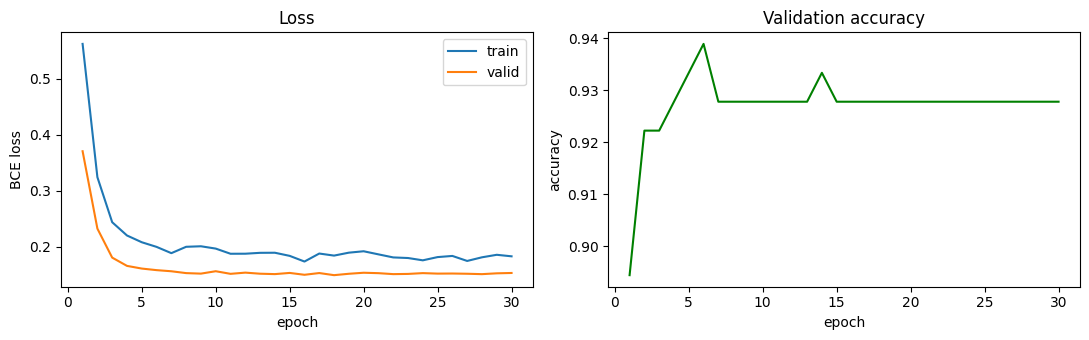

In [23]:
import matplotlib.pyplot as plt

ep  = [h[0] for h in history]
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(ep, [h[1] for h in history], label="train")
ax[0].plot(ep, [h[2] for h in history], label="valid")
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("BCE loss"); ax[0].legend(); ax[0].set_title("Loss")
ax[1].plot(ep, [h[3] for h in history], color="green")
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("accuracy"); ax[1].set_title("Validation accuracy")
plt.tight_layout(); plt.show()

---
## 11. 🔑 The tiny-subset overfit test

The most valuable thirty seconds in deep learning. Take 32 examples and train until the model **memorises** them.

| Outcome | Diagnosis |
|---|---|
| Cannot reach ~100% train accuracy on 32 examples | You have a **bug** — wrong loss pairing, targets not in the graph, params missing from the optimiser, absurd LR |
| Memorises them but validation is bad | Pipeline is **correct** — you have a **generalisation** problem |

Run this *before* touching a single hyperparameter.

In [24]:
def tiny_overfit_test(n=32, epochs=300, lr=1e-2, verbose=True):
    torch.manual_seed(SEED)
    xs, ys = X_train[:n].to(device), y_train[:n].to(device)
    m   = TicketMLP(3, 32, p_drop=0.0).to(device)     # dropout OFF -- we WANT memorisation
    opt = torch.optim.Adam(m.parameters(), lr=lr)
    fn  = nn.BCEWithLogitsLoss()
    for e in range(epochs):
        m.train()
        loss = fn(m(xs), ys)
        opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
    m.eval()
    with torch.inference_mode():
        acc = ((m(xs).sigmoid() >= 0.5) == ys.bool()).float().mean().item()
    if verbose:
        print(f"n={n} lr={lr}  final loss {loss.item():.5f}  train accuracy {acc:.3f}")
    return acc

acc = tiny_overfit_test()
print("PASS -- pipeline is wired correctly" if acc > 0.95
      else "FAIL -- there is a BUG, do not tune hyperparameters yet")

n=32 lr=0.01  final loss 0.02633  train accuracy 1.000
PASS -- pipeline is wired correctly


### What failure looks like — LR too high and LR too low

In [25]:
for lr in [10.0, 1e-2, 1e-6]:
    tiny_overfit_test(lr=lr)
print("\nlr=10.0  -> diverges / stuck: steps overshoot the minimum every time")
print("lr=1e-6  -> barely moves: correct direction, absurdly small steps")
print("Both LOOK like the same failure from the loss value. The cure is opposite.")

n=32 lr=10.0  final loss 0.00000  train accuracy 1.000
n=32 lr=0.01  final loss 0.02633  train accuracy 1.000
n=32 lr=1e-06  final loss 0.53960  train accuracy 0.812

lr=10.0  -> diverges / stuck: steps overshoot the minimum every time
lr=1e-6  -> barely moves: correct direction, absurdly small steps
Both LOOK like the same failure from the loss value. The cure is opposite.


---
## 12. Saving and loading

Save the **state dict**, not the model object.

| Approach | Pros | Cons |
|---|---|---|
| `state_dict` ✅ | portable, small, survives refactors | must recreate the class first |
| `torch.save(model)` | one line | breaks when your code moves or renames |

⚠️ Pickle files can execute arbitrary code. **Only load checkpoints you trust.** `weights_only=True` narrows the attack surface.

In [26]:
import tempfile, os

path = os.path.join(tempfile.gettempdir(), "ticket_model.pt")
torch.save({
    "epoch": EPOCHS,
    "model_state": model.state_dict(),
    "optimizer_state": optimizer.state_dict(),
    "feature_mean": mu, "feature_std": sd,          # metadata matters as much as weights!
    "val_metrics": evaluate(model, valid_loader, loss_fn, device),
    "seed": SEED,
}, path)

fresh = TicketMLP(3, 16).to(device)
ckpt  = torch.load(path, map_location=device, weights_only=True)
fresh.load_state_dict(ckpt["model_state"])

before = evaluate(model, test_loader, loss_fn, device)["accuracy"]
after  = evaluate(fresh, test_loader, loss_fn, device)["accuracy"]
print(f"original {before:.4f}  reloaded {after:.4f}  identical={before == after}")
print("saved keys:", list(ckpt.keys()))

original 0.9389  reloaded 0.9389  identical=True
saved keys: ['epoch', 'model_state', 'optimizer_state', 'feature_mean', 'feature_std', 'val_metrics', 'seed']


---
## 13. Debugging 

Reading tracebacks fluently is a skill. Here are the six you will actually meet.

In [27]:
m = TicketMLP(3, 8).to(device)
xb, yb = next(iter(train_loader))
xb, yb = xb.to(device), yb.to(device)

def show(label, fn):
    try:
        fn(); print(f"{label:<22} (no error)")
    except Exception as e:
        print(f"{label:<22} {type(e).__name__}: {str(e)[:95]}")

show("int features",   lambda: m(xb.long()))
show("wrong in_features", lambda: nn.Linear(99, 1).to(device)(xb))
show("target (N,) vs (N,1)", lambda: nn.BCEWithLogitsLoss()(m(xb), yb.squeeze(1)))
show("one-hot into CE", lambda: nn.CrossEntropyLoss()(torch.randn(4, 3), torch.eye(3)[[0,1,2,0]]))
show("backward twice", lambda: [nn.BCEWithLogitsLoss()(m(xb), yb).backward(),
                                nn.BCEWithLogitsLoss()(m(xb), yb).backward()][0])
show("backward on detached", lambda: (m(xb).detach().sum()).backward())

int features           RuntimeError: MPS device does not support linear for non-float inputs
wrong in_features      RuntimeError: linear(): input and weight.T shapes cannot be multiplied (32x3 and 99x1)
target (N,) vs (N,1)   ValueError: Target size (torch.Size([32])) must be the same as input size (torch.Size([32, 1]))
one-hot into CE        (no error)
backward twice         (no error)
backward on detached   RuntimeError: element 0 of tensors does not require grad and does not have a grad_fn


| Error message | Real cause | Fix |
|---|---|---|
| `expected scalar type Float but found Long` | integer features into `nn.Linear` | `x.float()` |
| `Expected all tensors on the same device` | forgot `.to(device)` | move batch **and** model |
| `mat1 and mat2 shapes cannot be multiplied` | wrong `in_features` | print shape before the layer |
| `Target size must be the same as input size` | `(N,)` vs `(N,1)` | `y.unsqueeze(1)` |
| `0D or 1D target tensor expected` | one-hot into CrossEntropy | pass class indices `.long()` |
| `element 0 ... does not require grad` | graph broken (`detach`, numpy round-trip) | keep the graph intact |
| loss exactly constant | missing `zero_grad`, LR=0, params not in optimiser | `print(len(optimizer.param_groups[0]['params']))` |

### The silent killers (no traceback, wrong results)

1. `(N,1)` vs `(N,)` broadcasting in the loss.
2. Sigmoid in the model **and** `BCEWithLogitsLoss`.
3. Standardising with statistics from the whole dataset (test leakage).
4. `shuffle=True` on the validation loader.
5. `total_loss += loss` instead of `.item()` (memory, not correctness).